# 1) Gerekli kütüphaneler

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

# 2) Veri setini okuma

In [53]:
# Dosya yolunu raw string (r"") ile yazmak Windows için daha güvenlidir.
df = pd.read_excel(r"Dataset\outlier_odevi_dataset.xlsx")

# İlk birkaç satırı kontrol ediyoruz
display(df.head())

,Öğrenci_ID,Yaş,Günlük_Uyku_Saat,Haftalık_Çalışma_Saat,Aylık_Gelir_TL,Not_Ortalaması,Günlük_Ekran_Süresi_Saat,Boy_cm,Kilo_kg,Devamsızlık_Gün
0,S001,22,6.9,23.2,11046,2.68,4.6,185,79,2
1,S002,22,6.5,17.7,8484,1.84,2.4,168,58,4
2,S003,20,5.6,27.3,7548,2.83,2.9,168,71,1
3,S004,22,6.4,18.5,6797,3.73,5.0,164,80,1
4,S005,21,1.0,13.4,8394,3.17,5.3,171,66,0


# 3) Veri setini genel olarak inceleme

In [54]:
# Sütun tipleri, boş değer durumu ve kayıt sayısı
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Öğrenci_ID                50 non-null     object 
 1   Yaş                       50 non-null     int64  
 2   Günlük_Uyku_Saat          50 non-null     float64
 3   Haftalık_Çalışma_Saat     50 non-null     float64
 4   Aylık_Gelir_TL            50 non-null     int64  
 5   Not_Ortalaması            50 non-null     float64
 6   Günlük_Ekran_Süresi_Saat  50 non-null     float64
 7   Boy_cm                    50 non-null     int64  
 8   Kilo_kg                   50 non-null     int64  
 9   Devamsızlık_Gün           50 non-null     int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 4.0+ KB


In [55]:
# Sayısal sütunların temel istatistikleri
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Yaş,50.0,21.7600,3.628459,18.00,20.25,21.00,22.000,45.00
Günlük_Uyku_Saat,50.0,6.8380,1.397358,1.00,6.20,6.90,7.800,10.50
Haftalık_Çalışma_Saat,50.0,20.5600,8.593092,3.00,16.65,19.25,23.275,65.00
Aylık_Gelir_TL,50.0,8878.8200,5411.082512,5359.00,7036.50,8197.50,8930.250,45000.00
Not_Ortalaması,50.0,2.7354,0.666906,0.12,2.32,2.71,3.165,3.96
Günlük_Ekran_Süresi_Saat,50.0,5.6280,2.175282,2.40,4.60,5.45,6.400,16.50
Boy_cm,50.0,170.9000,7.728162,155.00,166.00,171.50,175.000,188.00
Kilo_kg,50.0,70.0600,14.864572,46.00,61.25,68.50,74.000,135.00
Devamsızlık_Gün,50.0,3.7000,3.949942,0.00,2.00,3.00,4.000,28.00


In [56]:
# Eksik değer kontrolü
display(df.isnull().sum())

Öğrenci_ID                  0
Yaş                         0
Günlük_Uyku_Saat            0
Haftalık_Çalışma_Saat       0
Aylık_Gelir_TL              0
Not_Ortalaması              0
Günlük_Ekran_Süresi_Saat    0
Boy_cm                      0
Kilo_kg                     0
Devamsızlık_Gün             0
dtype: int64

In [57]:
# Tekrarlı kayıt kontrolü
print("Tekrarlı kayıt sayısı:", df.duplicated().sum())

Tekrarlı kayıt sayısı: 0


# 4) Analizde kullanılacak sayısal sütunlar

In [58]:
# Öğrenci_ID kimlik sütunu olduğu için sayısal analizde kullanmıyoruz.
numeric_cols = [
    "Yaş",
    "Günlük_Uyku_Saat",
    "Haftalık_Çalışma_Saat",
    "Aylık_Gelir_TL",
    "Not_Ortalaması",
    "Günlük_Ekran_Süresi_Saat",
    "Boy_cm",
    "Kilo_kg",
    "Devamsızlık_Gün"
]

# 5) Yardımcı fonksiyonlar

In [59]:
def calculate_iqr_outliers(dataframe, columns):
    """
    IQR yöntemine göre aykırı değerleri hesaplar.
    Geriye:
    - özet tablo
    - aykırı değer maskesi
    döndürür.
    """
    outlier_summary = []
    outlier_mask = pd.DataFrame(index=dataframe.index)

    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        current_mask = (dataframe[col] < lower_limit) | (dataframe[col] > upper_limit)
        outlier_mask[col] = current_mask

        outlier_summary.append({
            "Sütun": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "Alt_Sınır": round(lower_limit, 2),
            "Üst_Sınır": round(upper_limit, 2),
            "Aykırı_Değer_Sayısı": int(current_mask.sum())
        })

    outlier_df = pd.DataFrame(outlier_summary)
    return outlier_df, outlier_mask

In [60]:
def plot_box_grid(dataframe, columns, main_title):
    """
    Her sayısal değişken için ayrı kutu grafiği çizer.
    """
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        axes[i].boxplot(
            dataframe[col].dropna(),
            vert=True,
            patch_artist=True,
            showfliers=True
        )
        axes[i].set_title(col)
        axes[i].set_ylabel("Değer")
        axes[i].grid(alpha=0.3)

    plt.suptitle(main_title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [61]:
def plot_standardized_boxplot(dataframe, columns, title):
    """
    Tüm sayısal değişkenleri Z-skoruna dönüştürüp tek bir kutu grafikte gösterir.
    """
    scaled_df = dataframe[columns].copy()

    for col in columns:
        mean_val = scaled_df[col].mean()
        std_val = scaled_df[col].std()
        if std_val != 0:
            scaled_df[col] = (scaled_df[col] - mean_val) / std_val
        else:
            scaled_df[col] = 0

    plt.figure(figsize=(14, 6))
    plt.boxplot(
        [scaled_df[col].dropna() for col in columns],
        labels=columns,
        patch_artist=True,
        showfliers=True
    )
    plt.title(title)
    plt.ylabel("Z-Skoru")
    plt.xticks(rotation=45, ha="right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [62]:
def plot_gaussian_grid(dataframe, columns, main_title):
    """
    Her değişken için histogram + teorik Gaussian eğrisi çizer.
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        data = dataframe[col].dropna()

        mean_val = data.mean()
        std_val = data.std()

        axes[i].hist(data, bins=10, density=True, alpha=0.7, edgecolor="black")

        x = np.linspace(data.min(), data.max(), 200)

        if std_val != 0:
            gaussian_curve = (
                1 / (std_val * np.sqrt(2 * np.pi))
            ) * np.exp(-0.5 * ((x - mean_val) / std_val) ** 2)
            axes[i].plot(x, gaussian_curve, linewidth=2)

        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Yoğunluk")
        axes[i].grid(alpha=0.3)

    plt.suptitle(main_title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [63]:
def plot_qq_grid(dataframe, columns, main_title):
    """
    Her değişken için Q-Q Plot çizer.
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        data = dataframe[col].dropna()
        stats.probplot(data, dist="norm", plot=axes[i])
        axes[i].set_title(f"{col} Q-Q Plot")
        axes[i].grid(alpha=0.3)

    plt.suptitle(main_title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [64]:
def run_normality_tests(dataframe, columns, dataset_name):
    """
    Her sütun için:
    - Shapiro-Wilk testi
    - Kolmogorov-Smirnov testi

    uygular ve sonuçları tablo olarak döndürür.
    """
    results = []

    for col in columns:
        data = dataframe[col].dropna()

        if data.std() == 0:
            results.append({
                "Veri_Seti": dataset_name,
                "Sütun": col,
                "Shapiro_Stat": np.nan,
                "Shapiro_p": np.nan,
                "Shapiro_Yorum": "Sabit veri",
                "KS_Stat": np.nan,
                "KS_p": np.nan,
                "KS_Yorum": "Sabit veri"
            })
            continue

        # Shapiro-Wilk testi
        shapiro_stat, shapiro_p = stats.shapiro(data)

        # KS testi için veriyi standartlaştırıyoruz
        z_data = (data - data.mean()) / data.std()

        # Standart normal dağılıma karşı KS testi
        ks_stat, ks_p = stats.kstest(z_data, "norm")

        shapiro_comment = "Normale yakın" if shapiro_p > 0.05 else "Normal değil"
        ks_comment = "Normale yakın" if ks_p > 0.05 else "Normal değil"

        results.append({
            "Veri_Seti": dataset_name,
            "Sütun": col,
            "Shapiro_Stat": round(shapiro_stat, 4),
            "Shapiro_p": round(shapiro_p, 4),
            "Shapiro_Yorum": shapiro_comment,
            "KS_Stat": round(ks_stat, 4),
            "KS_p": round(ks_p, 4),
            "KS_Yorum": ks_comment
        })

    return pd.DataFrame(results)

# 6) IQR yöntemiyle aykırı değer tespiti

In [65]:
"""
Mantık:
- Q1 = %25'lik değer
- Q3 = %75'lik değer
- IQR = Q3 - Q1
- Alt sınır = Q1 - 1.5 * IQR
- Üst sınır = Q3 + 1.5 * IQR

Bu sınırların dışındaki değerleri aykırı kabul ediyoruz.
"""

outlier_df, outlier_mask = calculate_iqr_outliers(df, numeric_cols)

print("IQR yöntemine göre aykırı değer özeti:")
display(outlier_df)

IQR yöntemine göre aykırı değer özeti:


,Sütun,Q1,Q3,IQR,Alt_Sınır,Üst_Sınır,Aykırı_Değer_Sayısı
0,Yaş,20.25,22.00,1.75,17.62,24.62,1
1,Günlük_Uyku_Saat,6.20,7.80,1.60,3.80,10.20,3
2,Haftalık_Çalışma_Saat,16.65,23.28,6.62,6.71,33.21,3
3,Aylık_Gelir_TL,7036.50,8930.25,1893.75,4195.88,11770.88,1
4,Not_Ortalaması,2.32,3.16,0.84,1.05,4.43,1
5,Günlük_Ekran_Süresi_Saat,4.60,6.40,1.80,1.90,9.10,1
6,Boy_cm,166.00,175.00,9.00,152.50,188.50,0
7,Kilo_kg,61.25,74.00,12.75,42.12,93.12,2
8,Devamsızlık_Gün,2.00,4.00,2.00,-1.00,7.00,2


# 7) Aykırı değer içeren satırları gösterme

In [66]:
rows_with_outliers = df[outlier_mask.any(axis=1)].copy()

rows_with_outliers["Aykırı_Olan_Sütunlar"] = outlier_mask[outlier_mask.any(axis=1)].apply(
    lambda row: ", ".join(row.index[row.values]),
    axis=1
)

print("Toplam aykırı değer içeren satır sayısı:", rows_with_outliers.shape[0])
display(rows_with_outliers)

Toplam aykırı değer içeren satır sayısı: 13


,Öğrenci_ID,Yaş,Günlük_Uyku_Saat,Haftalık_Çalışma_Saat,Aylık_Gelir_TL,Not_Ortalaması,Günlük_Ekran_Süresi_Saat,Boy_cm,Kilo_kg,Devamsızlık_Gün,Aykırı_Olan_Sütunlar
4,S005,21,1.0,13.4,8394,3.17,5.3,171,66,0,Günlük_Uyku_Saat
8,S009,21,10.5,3.0,9644,3.95,4.6,173,46,3,"Günlük_Uyku_Saat, Haftalık_Çalışma_Saat"
11,S012,21,5.6,17.9,45000,2.40,4.8,175,93,3,Aylık_Gelir_TL
17,S018,21,7.3,16.4,11732,0.12,3.2,177,58,5,Not_Ortalaması
19,S020,20,6.9,21.7,8553,3.21,5.0,184,67,8,Devamsızlık_Gün
20,S021,22,6.1,14.6,8965,2.69,6.1,155,110,1,Kilo_kg
23,S024,22,7.5,39.3,9142,3.37,6.4,177,66,5,Haftalık_Çalışma_Saat
24,S025,20,6.8,17.6,8164,3.96,16.5,177,51,2,Günlük_Ekran_Süresi_Saat
29,S030,21,3.8,14.9,7495,2.18,7.4,161,65,3,Günlük_Uyku_Saat
30,S031,23,5.6,25.8,8020,2.31,5.7,174,63,28,Devamsızlık_Gün


# 8) Temizlik öncesi kutu grafikleri

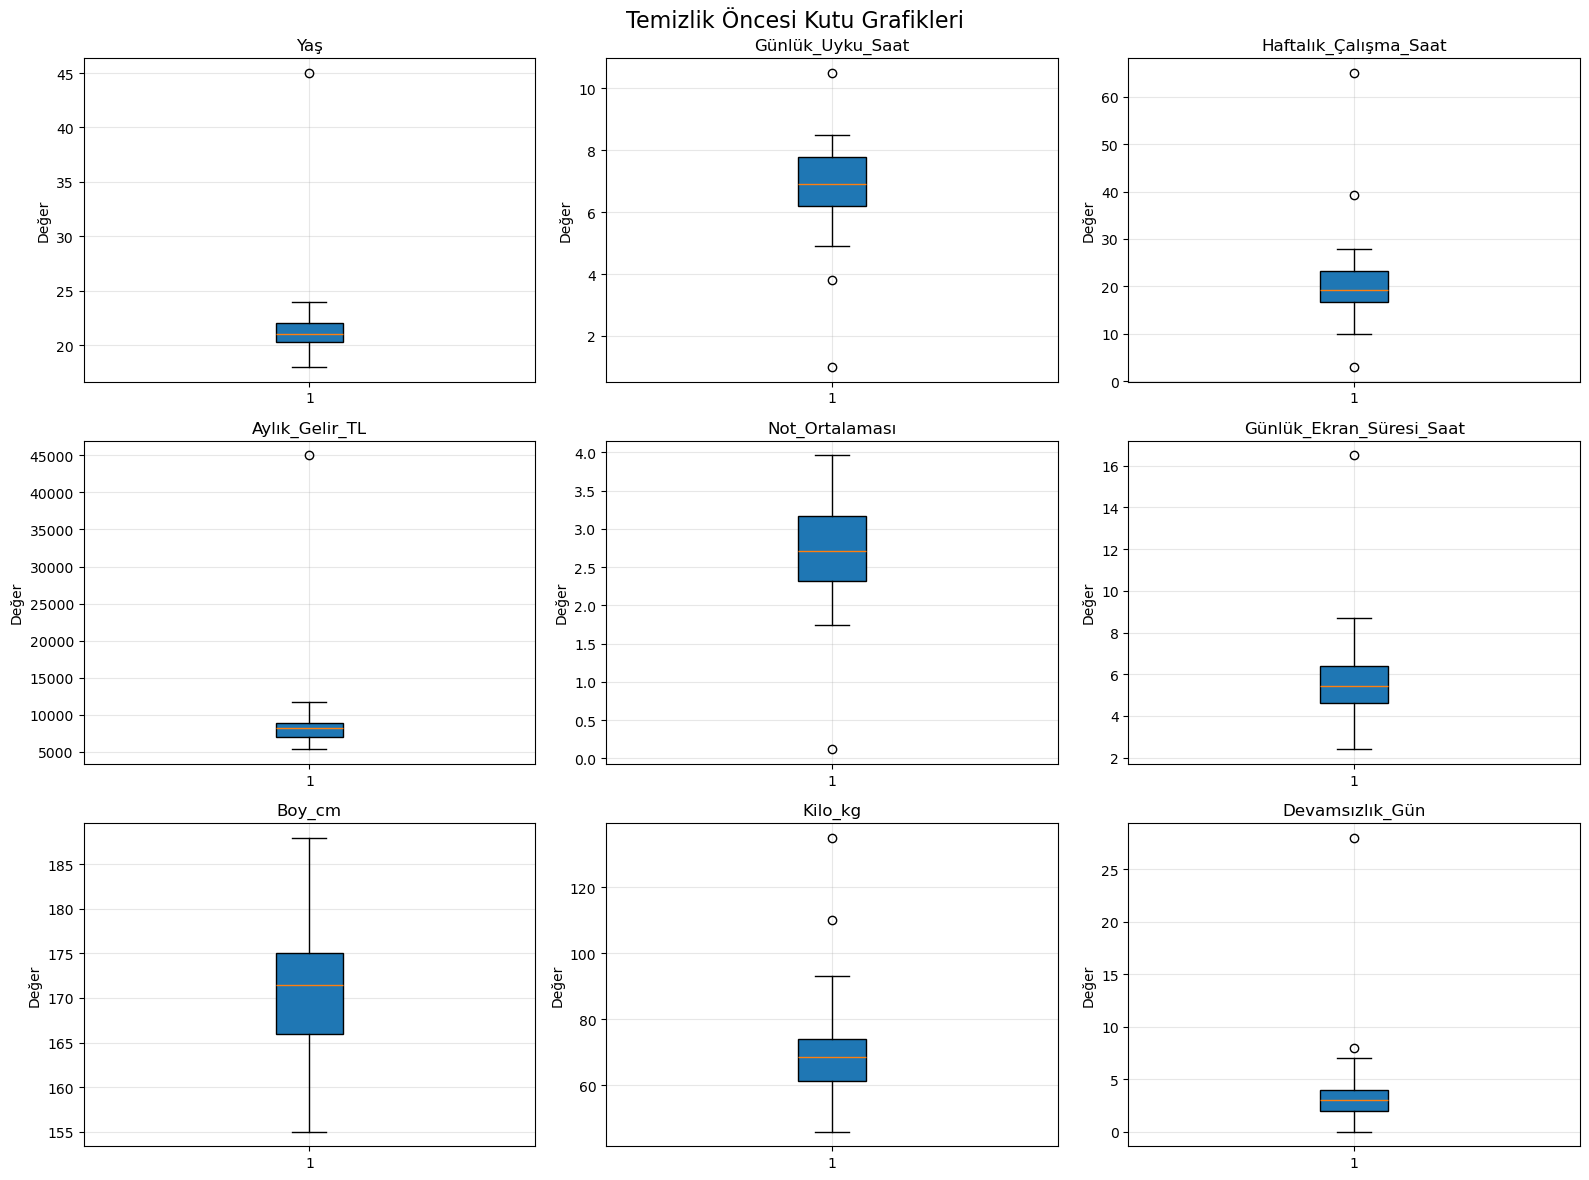

In [67]:
plot_box_grid(df, numeric_cols, "Temizlik Öncesi Kutu Grafikleri")

### Genel yorum
- Veri setinde birden fazla değişkende belirgin aykırı değer vardır.
- Özellikle üst kuyrukta yer alan aykırı değerler dağılımı bozmakta ve kutu + bıyık yapısını yukarı doğru çekmektedir.
- `Boy_cm` değişkeni diğerlerine göre daha dengeli görünmektedir.

### Değişken bazlı yorum
- **Yaş:** Merkez 20–22 aralığındadır. `45` çok belirgin bir üst aykırı değerdir.
- **Günlük_Uyku_Saat:** Ana yoğunluk 6–8 saat civarındadır. `1` çok düşük, `10.5` ise yüksek aykırı değerdir.
- **Haftalık_Çalışma_Saat:** Çoğu değer 17–23 saat civarında toplanmıştır. `3` alt tarafta; `39` ve özellikle `65` üst tarafta aykırı değerdir.
- **Aylık_Gelir_TL:** Ana kitle 7.000–9.000 TL bandındadır. `45.000` çok güçlü bir üst aykırı değerdir.
- **Not_Ortalaması:** Merkezi dağılım yaklaşık 2.3–3.2 aralığındadır. `0.12` çok düşük aykırı değerdir.
- **Günlük_Ekran_Süresi_Saat:** Yoğunluk 4.5–6.5 saat bandındadır. `16.5` belirgin bir üst aykırı değerdir.
- **Boy_cm:** Yaklaşık 166–175 cm bandında daha düzgün bir dağılım vardır. Belirgin aykırı değer görünmemektedir.
- **Kilo_kg:** Ana kitle 60–74 kg civarındadır. `110` ve `135` üst aykırı değerlerdir.
- **Devamsızlık_Gün:** Ana yoğunluk 2–4 gün civarındadır. `8` hafif, `28` ise çok belirgin üst aykırı değerdir.

### Sonuç
Ham veri aşamasında aykırı değer sorunu özellikle `Yaş`, `Aylık_Gelir_TL`, `Haftalık_Çalışma_Saat`, `Günlük_Ekran_Süresi_Saat`, `Kilo_kg` ve `Devamsızlık_Gün` değişkenlerinde belirgindir.

# 9) Temizlik öncesi standartlaştırılmış kutu grafiği

C:\Users\USER\AppData\Local\Temp\ipykernel_19748\4218672610.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


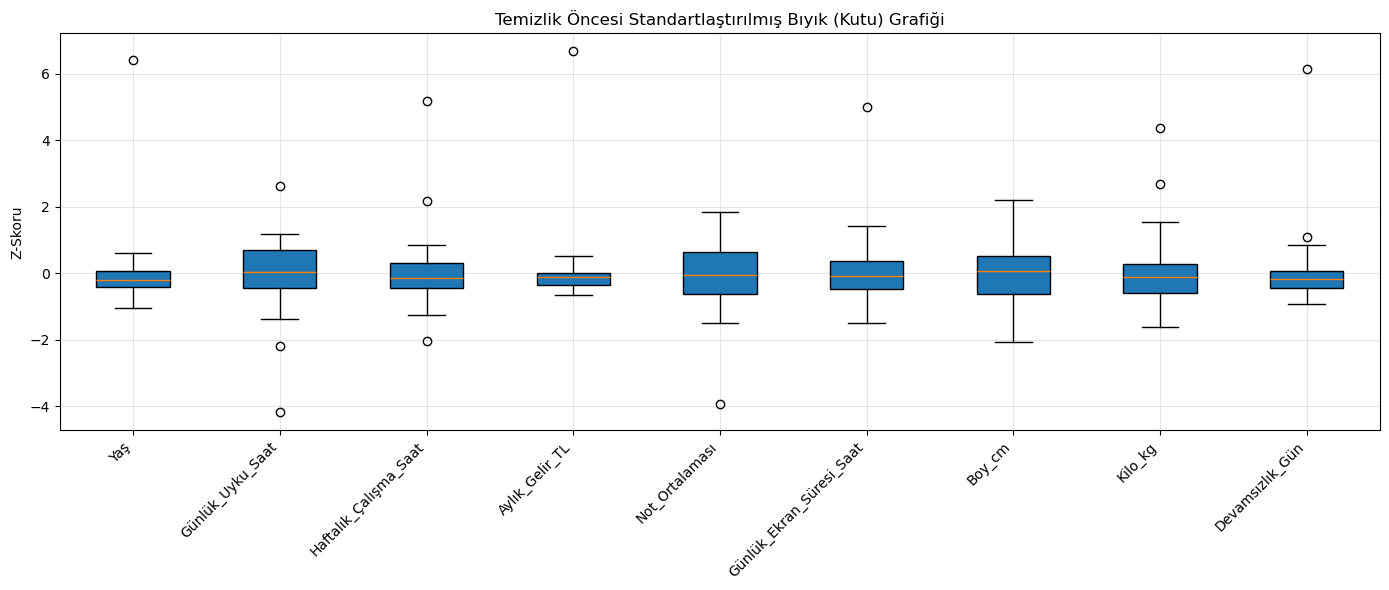

In [68]:
plot_standardized_boxplot(
    df,
    numeric_cols,
    "Temizlik Öncesi Standartlaştırılmış Bıyık (Kutu) Grafiği"
)

### Genel yorum
- Standartlaştırma sayesinde farklı birimlerdeki değişkenler doğrudan karşılaştırılabilmiştir.
- Medyanların büyük ölçüde `0` çevresinde toplanması beklenen ve doğru bir görüntüdür.
- Aykırı değerlerin göreli şiddeti bu grafikte çok daha net görülmektedir.

### Dikkat çeken noktalar
- **En güçlü pozitif aykırılar**: `Yaş`, `Aylık_Gelir_TL`, `Devamsızlık_Gün`, `Haftalık_Çalışma_Saat`, `Günlük_Ekran_Süresi_Saat`, `Kilo_kg`.
- **Belirgin negatif aykırılar**: `Günlük_Uyku_Saat` ve `Not_Ortalaması`.
- `Boy_cm` diğer değişkenlere göre daha sınırlı ve dengeli bir aralıkta kalmaktadır.

### Sonuç
Bu görsel, ham veride aykırı değerlerin yalnızca var olduğunu değil, aynı zamanda hangi değişkenlerde daha şiddetli olduğunu da göstermektedir. Aykırı değer problemi sadece tek bir sütuna özgü değildir. Veri seti genelinde çoklu değişkenleri etkilemektedir.

# 10) Temizlik öncesi Gaussian distribution grafikleri

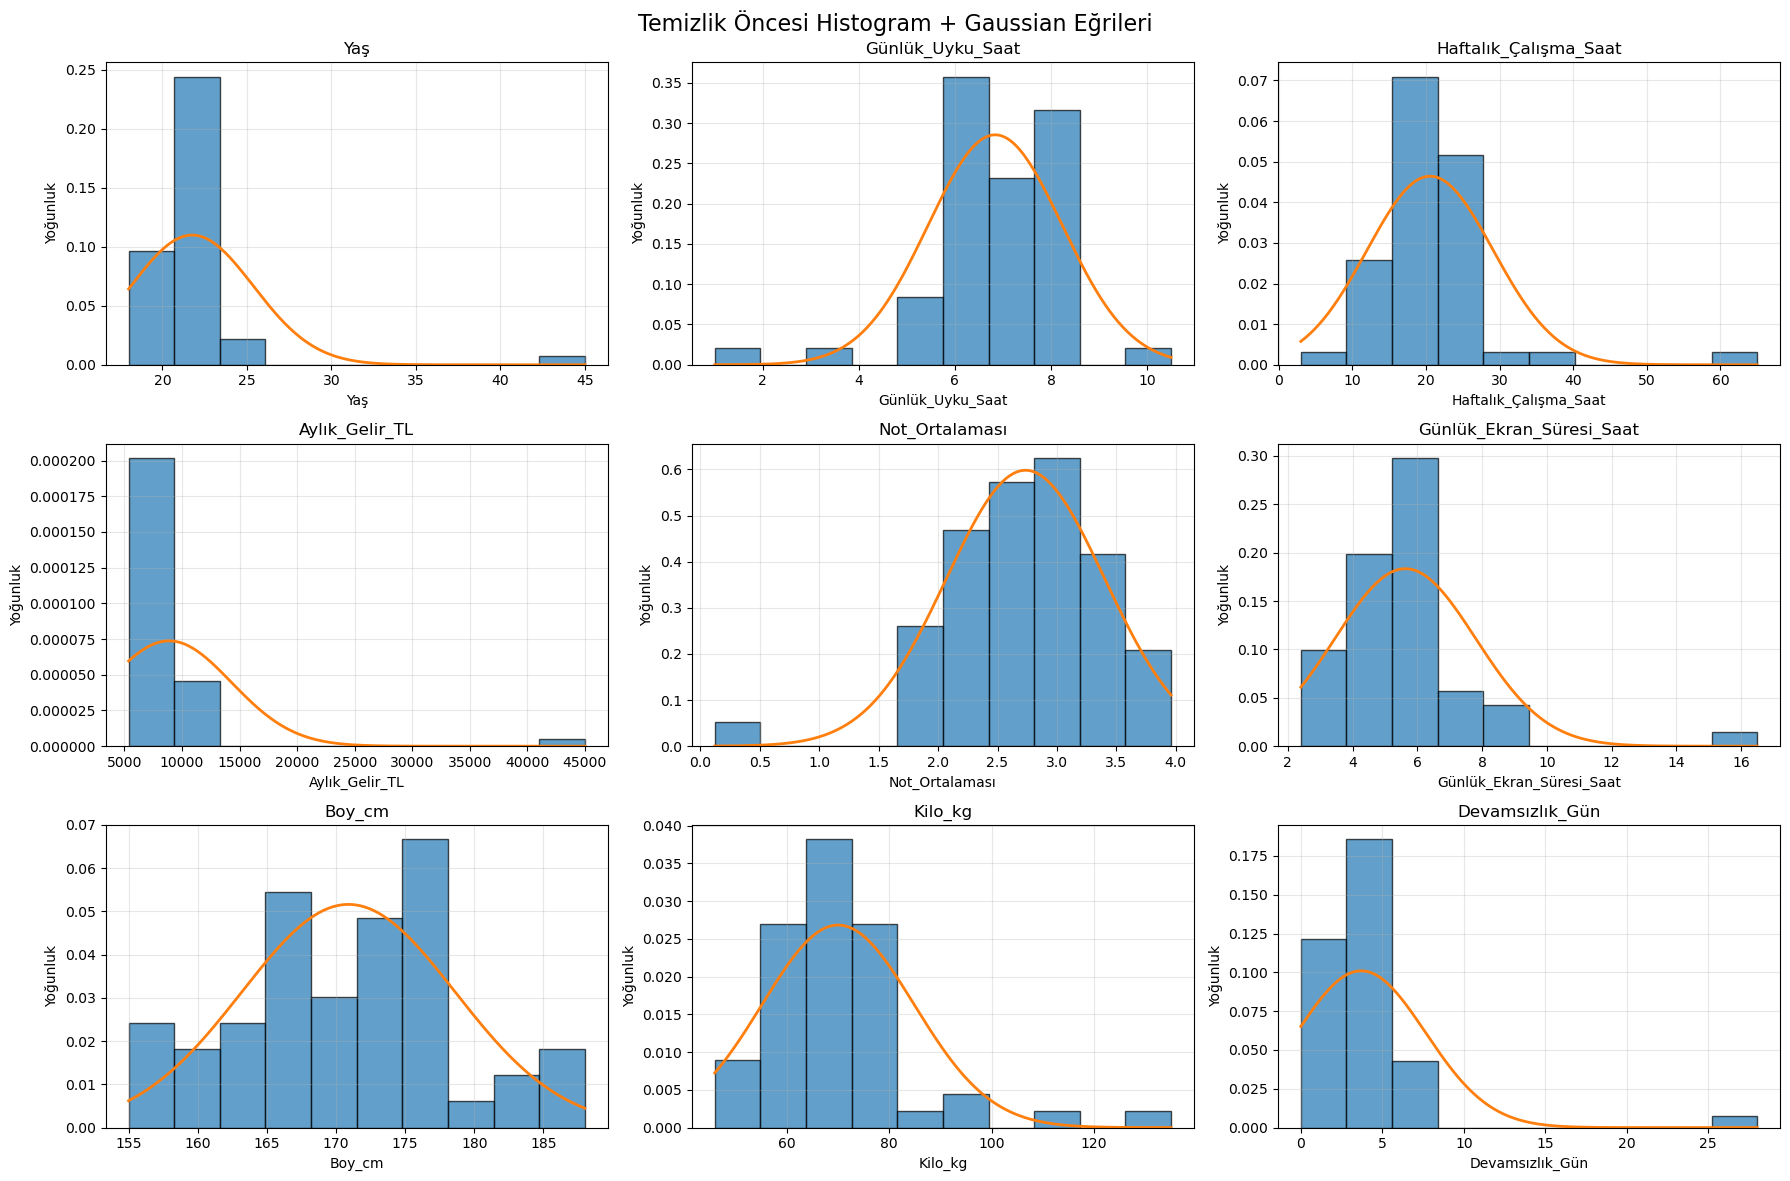

In [69]:
plot_gaussian_grid(
    df,
    numeric_cols,
    "Temizlik Öncesi Histogram + Gaussian Eğrileri"
)

### Genel yorum
- Ham veride birçok değişken normal dağılımdan sapmaktadır.
- Aykırı değerler histogram kuyruklarını uzatmakta ve Gaussian eğrisi ile uyumu bozmaktadır.
- Bu görsel, kutu grafiğinde görülen aykırı değerlerin dağılım formunu nasıl bozduğunu desteklemektedir.

### Değişken bazlı yorum
- **Yaş:** Yoğunluk 20–22 civarında toplansa da `45` nedeniyle sağ kuyruk ciddi şekilde uzamıştır.
- **Günlük_Uyku_Saat:** Orta kısımda görece dengeli görünüm vardır; ancak `1` ve `10.5` nedeniyle iki uç bozulmuştur.
- **Haftalık_Çalışma_Saat:** Ana kitle orta bölgede olsa da sağ kuyruk `39` ve `65` ile belirgin şekilde uzamıştır.
- **Aylık_Gelir_TL:** `45.000` sebebiyle çok kuvvetli sağa çarpıklık vardır; normal dağılım eğrisi ile uyum zayıftır.
- **Not_Ortalaması:** Orta kısım Gaussian eğrisine görece yakındır; ancak `0.12` alt kuyrukta bozulma yaratmaktadır.
- **Günlük_Ekran_Süresi_Saat:** Sağ kuyruk `16.5` nedeniyle uzamıştır.
- **Boy_cm:** En normal görünüme yakın değişkenlerden biridir; histogram ve teorik eğri nispeten uyumludur.
- **Kilo_kg:** Üst kuyruk `110` ve `135` sebebiyle uzamıştır; sağa çarpıklık vardır.
- **Devamsızlık_Gün:** Doğası gereği ayrık ve sağa çarpık bir yapı göstermektedir; `28` bu çarpıklığı güçlendirmektedir.

### Sonuç
Ham veri aşamasında, özellikle aykırı değer içeren değişkenlerde Gaussian eğrisi ile histogram arasındaki uyum zayıftır. `Boy_cm` ve kısmen `Not_Ortalaması` diğerlerine göre daha dengeli görünmektedir.

# 11) Aykırı değerleri temizleme - Yöntem 1: Satır silme

In [70]:
# En az bir sütunda aykırı değeri olan satırlar tamamen kaldırılır.
df_clean_drop = df[~outlier_mask.any(axis=1)].copy()

print("Satır silme yöntemi:")
print("Orijinal veri boyutu   :", df.shape)
print("Temizlenmiş veri boyutu:", df_clean_drop.shape)
print("Silinen satır sayısı   :", df.shape[0] - df_clean_drop.shape[0])

display(df_clean_drop.head())

Satır silme yöntemi:
Orijinal veri boyutu   : (50, 10)
Temizlenmiş veri boyutu: (37, 10)
Silinen satır sayısı   : 13


,Öğrenci_ID,Yaş,Günlük_Uyku_Saat,Haftalık_Çalışma_Saat,Aylık_Gelir_TL,Not_Ortalaması,Günlük_Ekran_Süresi_Saat,Boy_cm,Kilo_kg,Devamsızlık_Gün
0,S001,22,6.9,23.2,11046,2.68,4.6,185,79,2
1,S002,22,6.5,17.7,8484,1.84,2.4,168,58,4
2,S003,20,5.6,27.3,7548,2.83,2.9,168,71,1
3,S004,22,6.4,18.5,6797,3.73,5.0,164,80,1
5,S006,20,6.5,25.3,8687,1.92,5.5,169,62,4


# 12) Aykırı değerleri temizleme - Yöntem 2: Baskılama (Capping) [1]

In [71]:
# Uç değerler silinmez, alt/üst sınıra çekilir.
df_clean_capped = df.copy()

for col in numeric_cols:
    q1 = df_clean_capped[col].quantile(0.25)
    q3 = df_clean_capped[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    df_clean_capped[col] = df_clean_capped[col].apply(
        lambda x: lower_limit if x < lower_limit else upper_limit if x > upper_limit else x
    )

print("Baskılama (capping) yöntemi:")
print("Orijinal veri boyutu   :", df.shape)
print("Temizlenmiş veri boyutu:", df_clean_capped.shape)

display(df_clean_capped.head())

Baskılama (capping) yöntemi:
Orijinal veri boyutu   : (50, 10)
Temizlenmiş veri boyutu: (50, 10)


,Öğrenci_ID,Yaş,Günlük_Uyku_Saat,Haftalık_Çalışma_Saat,Aylık_Gelir_TL,Not_Ortalaması,Günlük_Ekran_Süresi_Saat,Boy_cm,Kilo_kg,Devamsızlık_Gün
0,S001,22.0,6.9,23.2,11046.0,2.68,4.6,185,79.0,2.0
1,S002,22.0,6.5,17.7,8484.0,1.84,2.4,168,58.0,4.0
2,S003,20.0,5.6,27.3,7548.0,2.83,2.9,168,71.0,1.0
3,S004,22.0,6.4,18.5,6797.0,3.73,5.0,164,80.0,1.0
4,S005,21.0,3.8,13.4,8394.0,3.17,5.3,171,66.0,0.0


# 13) Satır silme sonrası kutu grafikleri

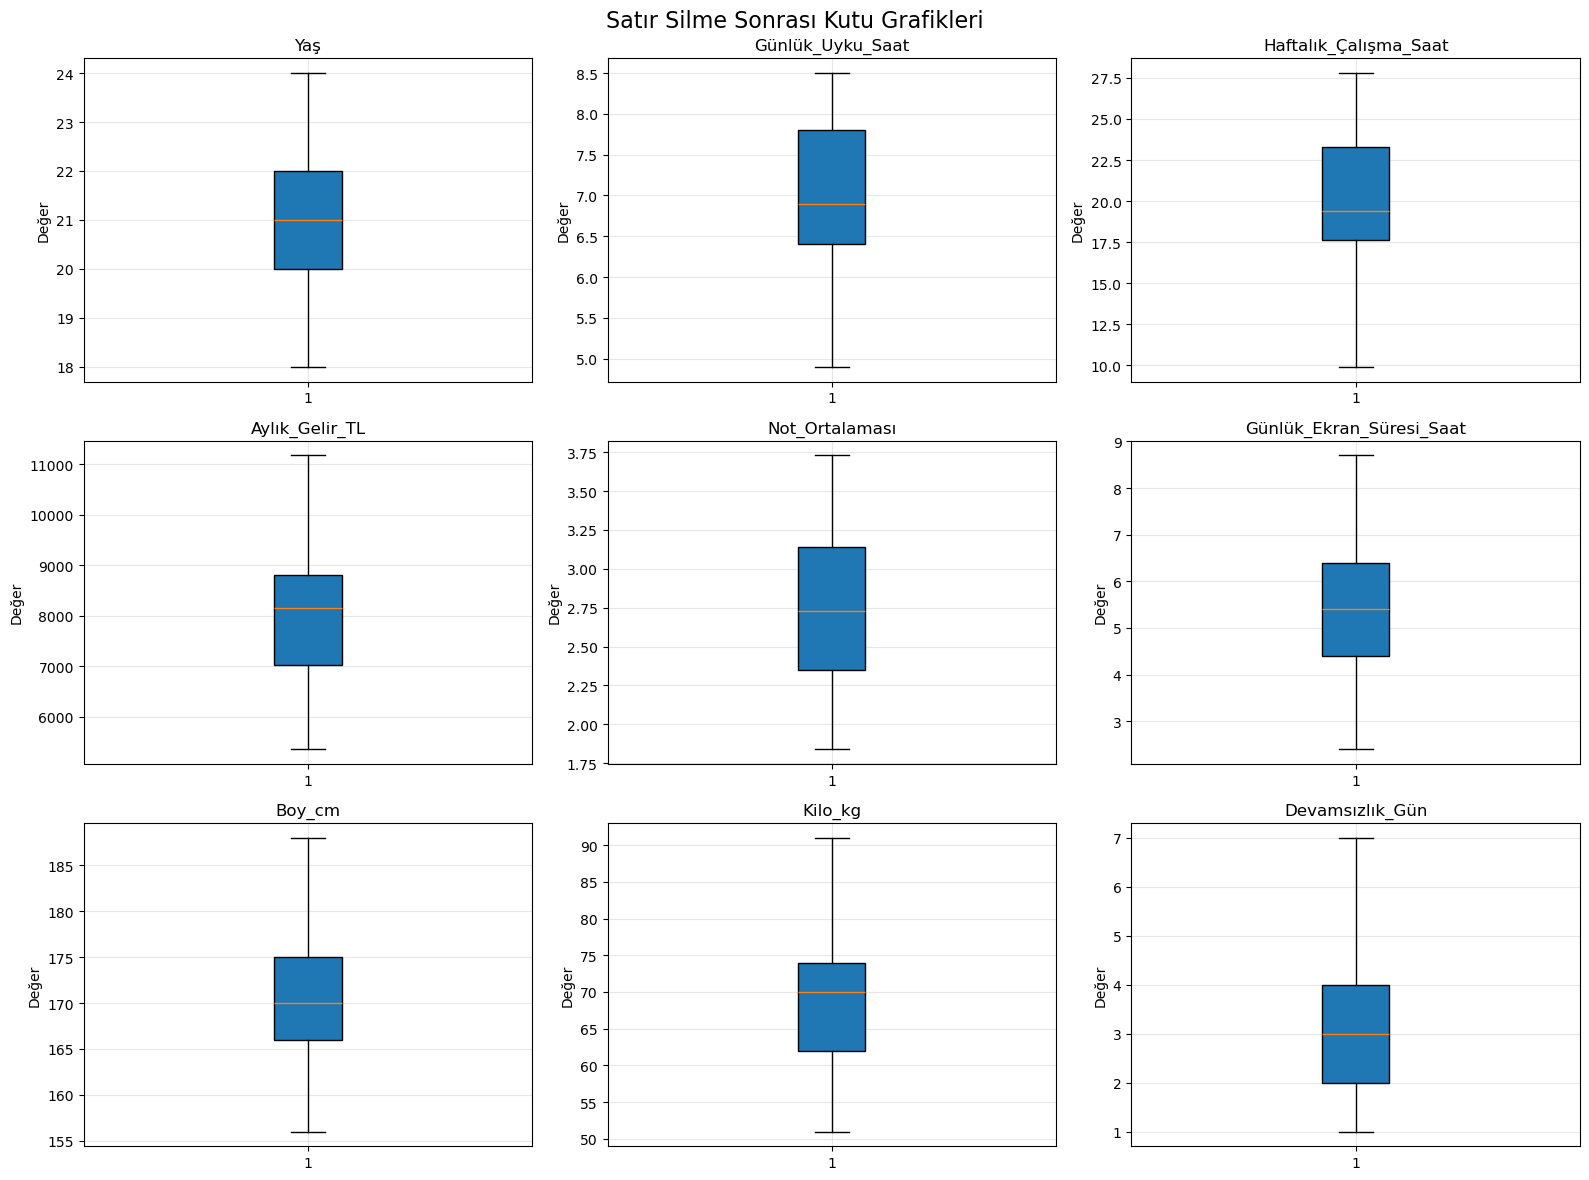

In [72]:
plot_box_grid(df_clean_drop, numeric_cols, "Satır Silme Sonrası Kutu Grafikleri")

### Genel yorum
- Kutu grafiğinde aykırı noktalar büyük ölçüde kaybolmuştur.
- Dağılımlar belirgin biçimde daralmış ve daha temiz hale gelmiştir.
- Bu yöntem aykırı değerleri etkili şekilde ortadan kaldırmıştır; ancak veri sayısını azaltmıştır.

### Değişken bazlı gözlemler
- **Yaş:** `45` çıkarıldığı için dağılım 18–24 aralığında düzgünleşmiştir.
- **Günlük_Uyku_Saat:** `1` ve `10.5` gibi uç değerler yoktur; bıyık yapısı daha dengelidir.
- **Haftalık_Çalışma_Saat:** Alt ve üst aykırı değerler temizlendiği için orta bant daha net görünmektedir.
- **Aylık_Gelir_TL:** `45.000` çıktığı için ciddi sağa çarpıklık azalmıştır.
- **Not_Ortalaması:** `0.12` kaldırıldığı için alt kuyruk temizlenmiştir.
- **Günlük_Ekran_Süresi_Saat:** `16.5` çıkarıldığı için daha dengeli bir görünüm vardır.
- **Boy_cm:** Zaten dengeli olduğu için görünümde radikal bir değişim yoktur.
- **Kilo_kg:** `110` ve `135` çıkarıldığı için üst kuyruk kısalmıştır.
- **Devamsızlık_Gün:** `28` ve yüksek uç noktalar çıkarıldığı için dağılım daha kompakt hale gelmiştir.

### Sonuç
Satır silme yöntemi, kutu grafiği açısından en temiz sonucu vermektedir. Aykırı değerler neredeyse tamamen ortadan kalkmıştır.

# 14) Baskılama sonrası kutu grafikleri

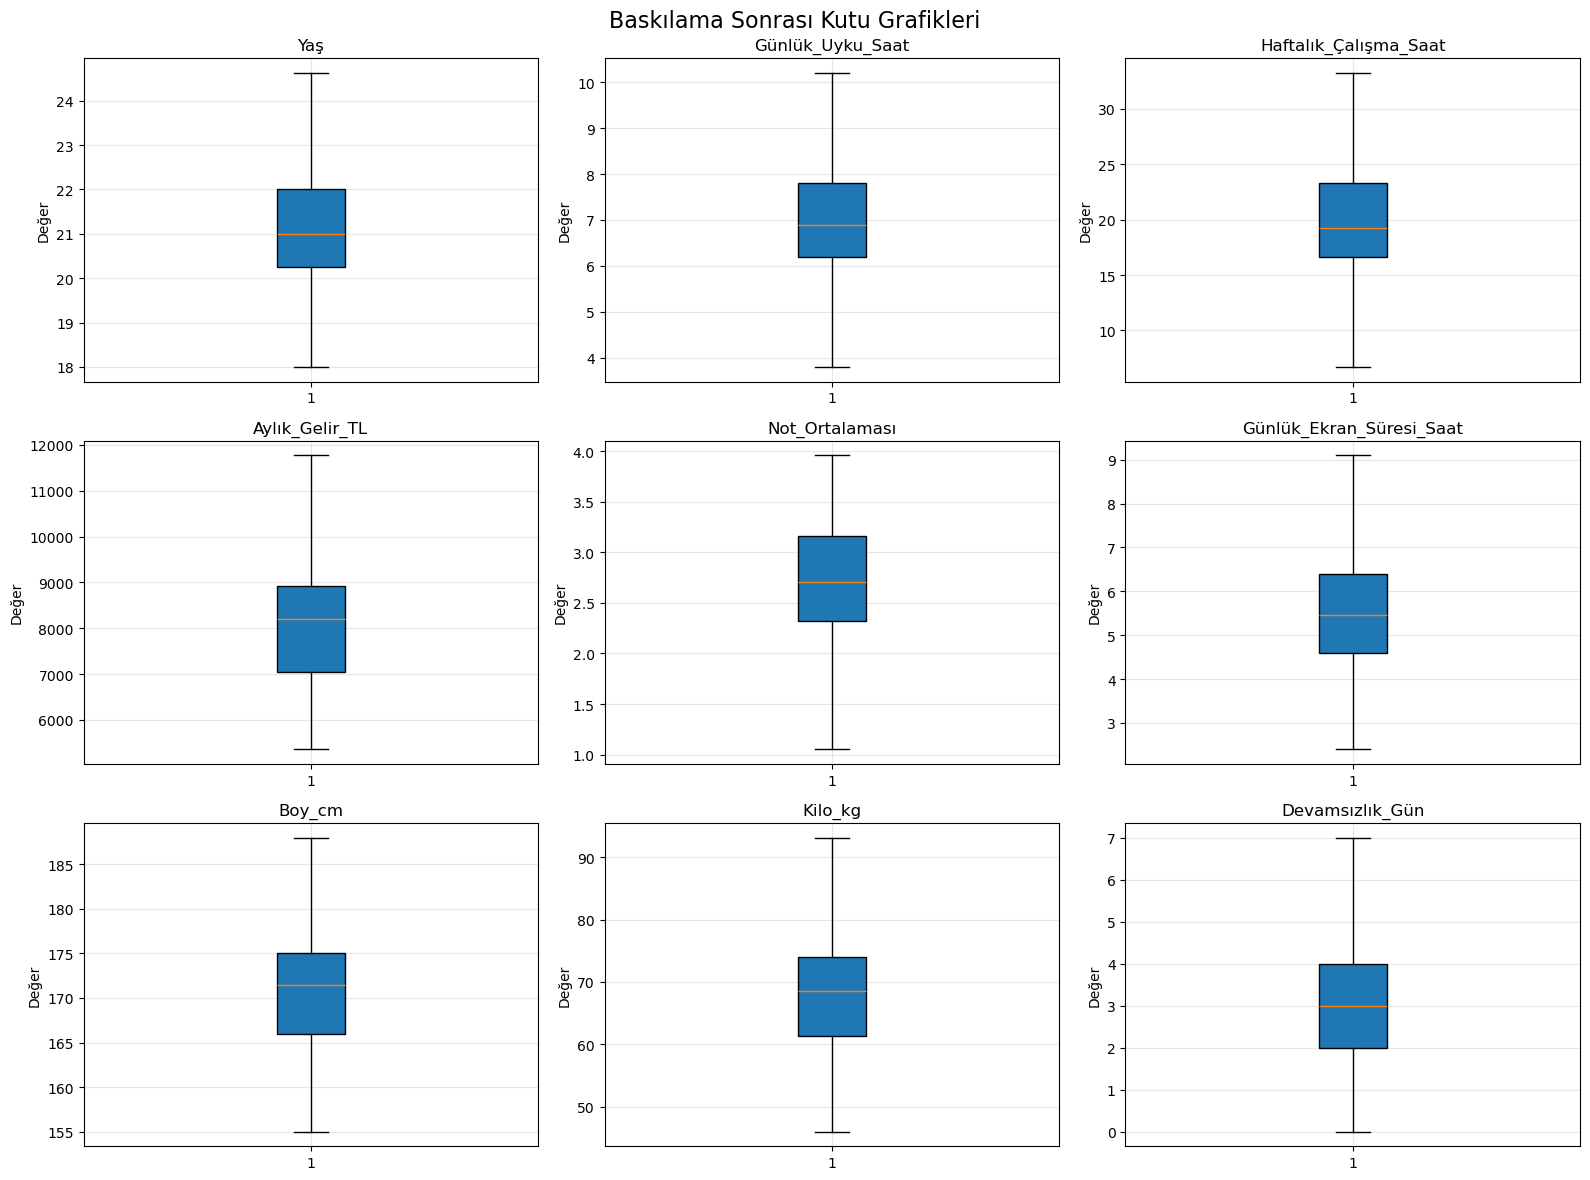

In [73]:
plot_box_grid(df_clean_capped, numeric_cols, "Baskılama Sonrası Kutu Grafikleri")

### Genel yorum
- Aykırı noktalar büyük ölçüde kaybolmuştur.
- Veri boyutu korunmuştur.
- Dağılımlar satır silmeye göre biraz daha yayvan kalmaktadır; çünkü veri tamamen silinmemiş, sadece sınırlandırılmıştır [1].

### Değişken bazlı gözlemler
- **Yaş:** `45`, üst sınıra çekildiği için artık ayrı bir nokta olarak görünmemekte; ancak dağılımın üst sınırını genişletmektedir.
- **Günlük_Uyku_Saat:** `1` ve `10.5` sınır değerlere çekildiği için dağılım daha dengeli, fakat uç kısımda yoğunlaşma hissi vardır.
- **Haftalık_Çalışma_Saat:** Yüksek uç noktalar sınıra çekildiği için orta kısım korunmuş, üst bıyık uzamıştır.
- **Aylık_Gelir_TL:** `45.000` sınıra çekildiği için ciddi bozulma azalmıştır, ancak üst tarafa doğru hâlâ genişleme vardır.
- **Not_Ortalaması:** Düşük aykırı değer alt sınıra yaklaşmış, dağılım korunmuştur.
- **Günlük_Ekran_Süresi_Saat:** Üst aykırı değer sınıra çekildiği için daha dengeli görünüm vardır.
- **Boy_cm:** Kayda değer değişim yoktur.
- **Kilo_kg:** Yüksek değerler üst sınıra çekildiği için dağılım korunurken üst bölgede birikme oluşmuştur.
- **Devamsızlık_Gün:** Üst aykırı değer sınıra çekildiği için orta bölge korunmuş, üst sınıra yakın değerler yoğunlaşmıştır.

### Sonuç
Baskılama yöntemi, veri kaybı olmadan aykırı değer etkisini azaltmıştır [1]. Ancak satır silmeye göre daha geniş bir dağılım korunmaktadır. Bu da beklenen ve doğru bir sonuçtur.

# 15) Satır silme sonrası Gaussian grafikleri

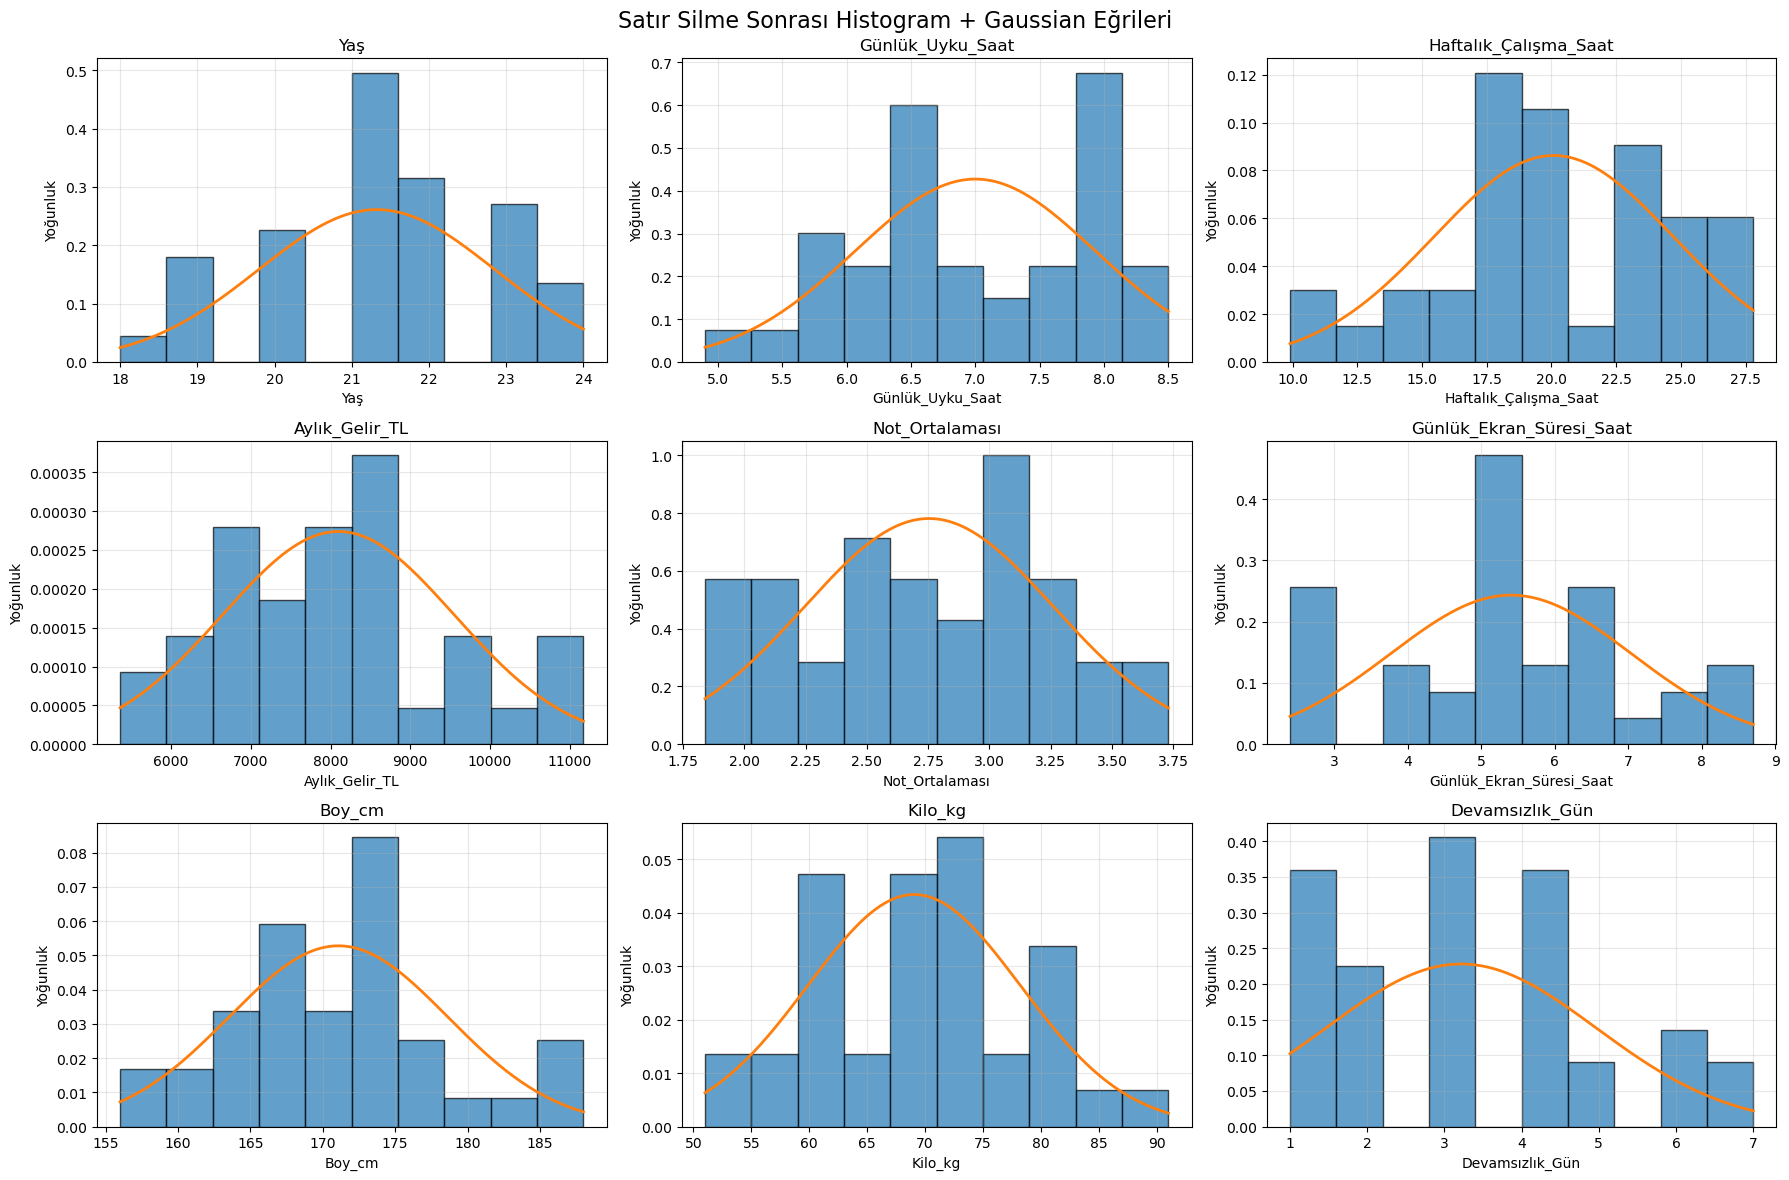

In [74]:
plot_gaussian_grid(
    df_clean_drop,
    numeric_cols,
    "Satır Silme Sonrası Histogram + Gaussian Eğrileri"
)

### Genel yorum
- Ham veriye göre histogramlar belirgin biçimde daha düzgün hale gelmiştir.
- Gaussian eğrileri ile uyum birçok değişkende gözle görülür şekilde artmıştır.
- Buna rağmen tüm değişkenler tamamen normal dağılıma dönüşmüş değildir.

### Değişken bazlı yorum
- **Yaş:** Sağ kuyruk kaybolduğu için önceye göre çok daha dengeli, ancak yaş değerleri ayrık ve dar aralıkta olduğu için mükemmel normal değildir.
- **Günlük_Uyku_Saat:** Orta bölgede Gaussian uyumu artmıştır; belirgin iyileşme vardır.
- **Haftalık_Çalışma_Saat:** Üst kuyruk kısa olduğu için eğrinin merkeze uyumu belirgin şekilde iyileşmiştir.
- **Aylık_Gelir_TL:** En belirgin iyileşmelerden biridir; `45.000` çıkarıldığı için sağa çarpıklık ciddi şekilde azalmıştır.
- **Not_Ortalaması:** Alt kuyruktaki bozulma azalmış, dağılım daha simetrik hale gelmiştir.
- **Günlük_Ekran_Süresi_Saat:** Çok yüksek değer kalktığı için orta bant daha dengelidir.
- **Boy_cm:** Zaten daha önce de görece uyumluydu; bu aşamada da normal dağılıma en yakın değişkenlerden biridir.
- **Kilo_kg:** Üst kuyruk kısalmış ve eğri ile uyum artmıştır.
- **Devamsızlık_Gün:** Ayrık yapı devam ettiği için tam normal değildir; ancak aşırı sağ kuyruk belirgin şekilde azalmıştır.

### Sonuç
Satır silme sonrası histogramlar, ham veriye göre normal dağılıma daha yakındır. En belirgin iyileşme `Aylık_Gelir_TL`, `Haftalık_Çalışma_Saat`, `Günlük_Ekran_Süresi_Saat`, `Kilo_kg` ve `Devamsızlık_Gün` değişkenlerinde görülmektedir.

# 16) Baskılama sonrası Gaussian grafikleri

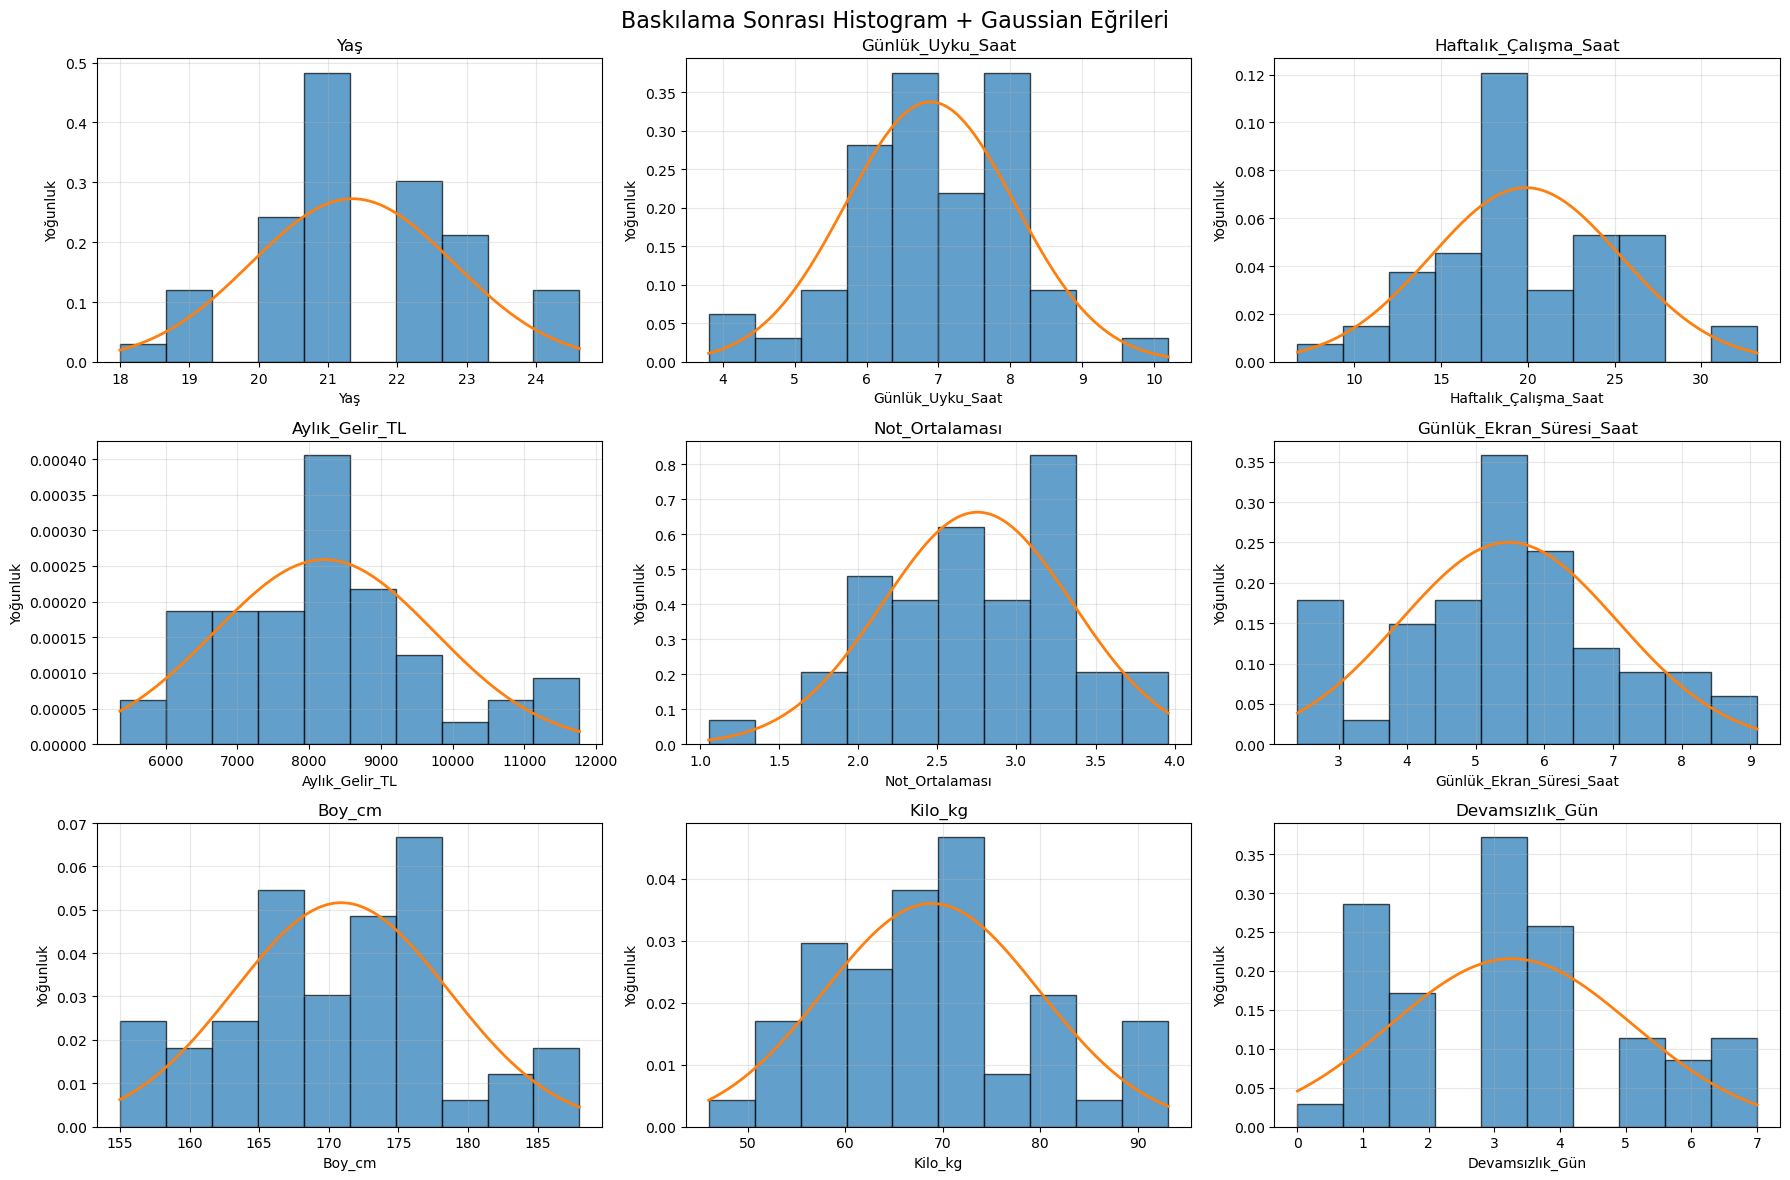

In [75]:
plot_gaussian_grid(
    df_clean_capped,
    numeric_cols,
    "Baskılama Sonrası Histogram + Gaussian Eğrileri"
)

### Genel yorum
- Ham veriye göre belirgin iyileşme vardır.
- Veri kaybı olmadığı için histogramlar satır silmeye göre biraz daha geniş kalmaktadır.
- Gaussian eğrisine uyum artmıştır; ancak sınıra çekilen değerler nedeniyle bazı değişkenlerde kenarlarda yığılma etkisi oluşmuştur.

### Değişken bazlı yorum
- **Yaş:** `45` üst sınıra çekildiği için ciddi bozulma kalkmıştır. Dağılım satır silmeye yakın, ancak üst uçta sınır etkisi vardır.
- **Günlük_Uyku_Saat:** Merkez kısım iyi görünmektedir. Alt ve üst uç değerler sınıra toplandığı için hafif kenar yoğunluğu vardır.
- **Haftalık_Çalışma_Saat:** Orta bant iyi korunmuş, üst kısım satır silmeye göre biraz daha geniştir.
- **Aylık_Gelir_TL:** Büyük aykırı değer sınıra çekildiği için ciddi iyileşme vardır; ancak üst tarafta hâlâ sınır etkili bir yayılma görülür.
- **Not_Ortalaması:** Orta kısım dengeli, alt tarafta önceki bozulma azalmıştır.
- **Günlük_Ekran_Süresi_Saat:** Sağ kuyruk ciddi şekilde toparlanmıştır.
- **Boy_cm:** Belirgin bir değişim yoktur, zaten dengeliydi.
- **Kilo_kg:** Yüksek değerler sınıra çekildiği için sağ kuyruk yumuşamıştır, ama üst kısımda yığılma görülür.
- **Devamsızlık_Gün:** Aşırı sağ kuyruk azalmıştır; yine de ayrık yapı nedeniyle tam normal görünmez.

### Sonuç
Baskılama yöntemi, histogramları ham veriye göre belirgin şekilde iyileştirmiştir. Ancak satır silmeye göre kuyruklar bir miktar daha korunmaktadır. Bunun nedeni verinin silinmemesi, sadece sınırlandırılmasıdır.

# 17) Orijinal veri için Q-Q Plot

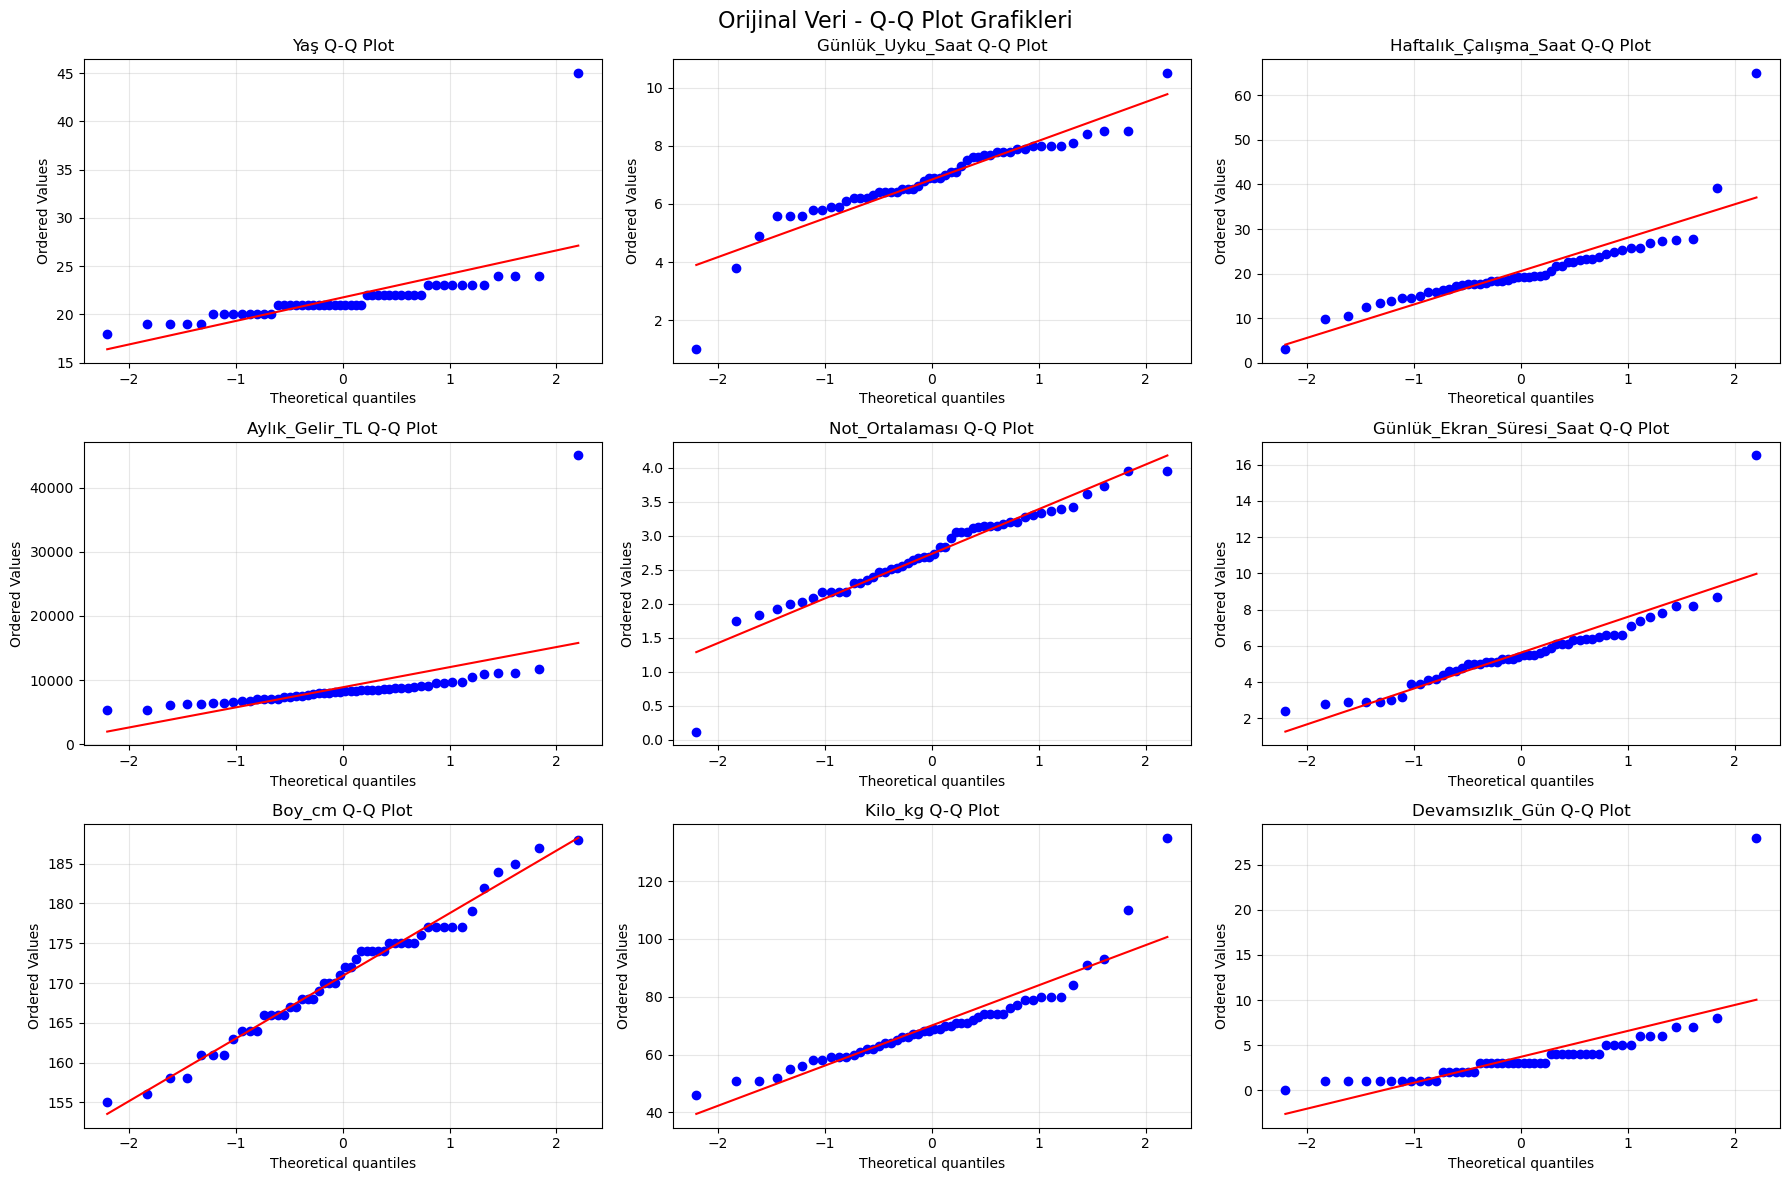

In [76]:
plot_qq_grid(df, numeric_cols, "Orijinal Veri - Q-Q Plot Grafikleri")

### Genel yorum
- Birçok değişkende noktalar referans çizgisinden belirgin şekilde sapmaktadır.
- Uçlarda (özellikle sağ üstte) sapmalar, aykırı değerlerin kuvvetli etkisini göstermektedir.
- Q-Q plot'lar ham verinin tüm değişkenlerde aynı düzeyde normal olmadığını açık biçimde göstermektedir.

### Değişken bazlı yorum
- **Yaş:** Sağ üstte `45` noktası çizgiden sert biçimde kopmaktadır; normal dağılıma uyum zayıftır.
- **Günlük_Uyku_Saat:** Merkezde fena olmayan uyum vardır; alt ve üst uçlarda sapma görülür.
- **Haftalık_Çalışma_Saat:** Üst uçta `39` ve `65` çizgiden ayrılmaktadır; sağ kuyruk problemi vardır.
- **Aylık_Gelir_TL:** `45.000` noktası çok sert sapma yaratmaktadır; normal uyum zayıftır.
- **Not_Ortalaması:** Merkezde iyiye yakın uyum vardır; `0.12` alt uçta bozulma yaratmaktadır.
- **Günlük_Ekran_Süresi_Saat:** Üst uçta `16.5` belirgin sapma vermektedir.
- **Boy_cm:** Noktalar referans çizgisine en yakın görünenlerden biridir; normal dağılıma en yakın değişkenlerden biridir.
- **Kilo_kg:** Üst uçta `110` ve `135` belirgin şekilde çizgiden ayrılmaktadır.
- **Devamsızlık_Gün:** Ayrık ve sağa çarpık yapı nedeniyle çizgiye uyum zayıftır; `28` çok güçlü sapmadır.

### Sonuç
Orijinal veride normalite açısından en sorunlu alanlar, aykırı değer içeren üst kuyruklardır. `Boy_cm` ve kısmen `Not_Ortalaması` daha iyi görünürken, `Aylık_Gelir_TL`, `Yaş`, `Haftalık_Çalışma_Saat`, `Kilo_kg` ve `Devamsızlık_Gün` daha zayıf uyum göstermektedir.

# 18) Satır silme sonrası Q-Q Plot

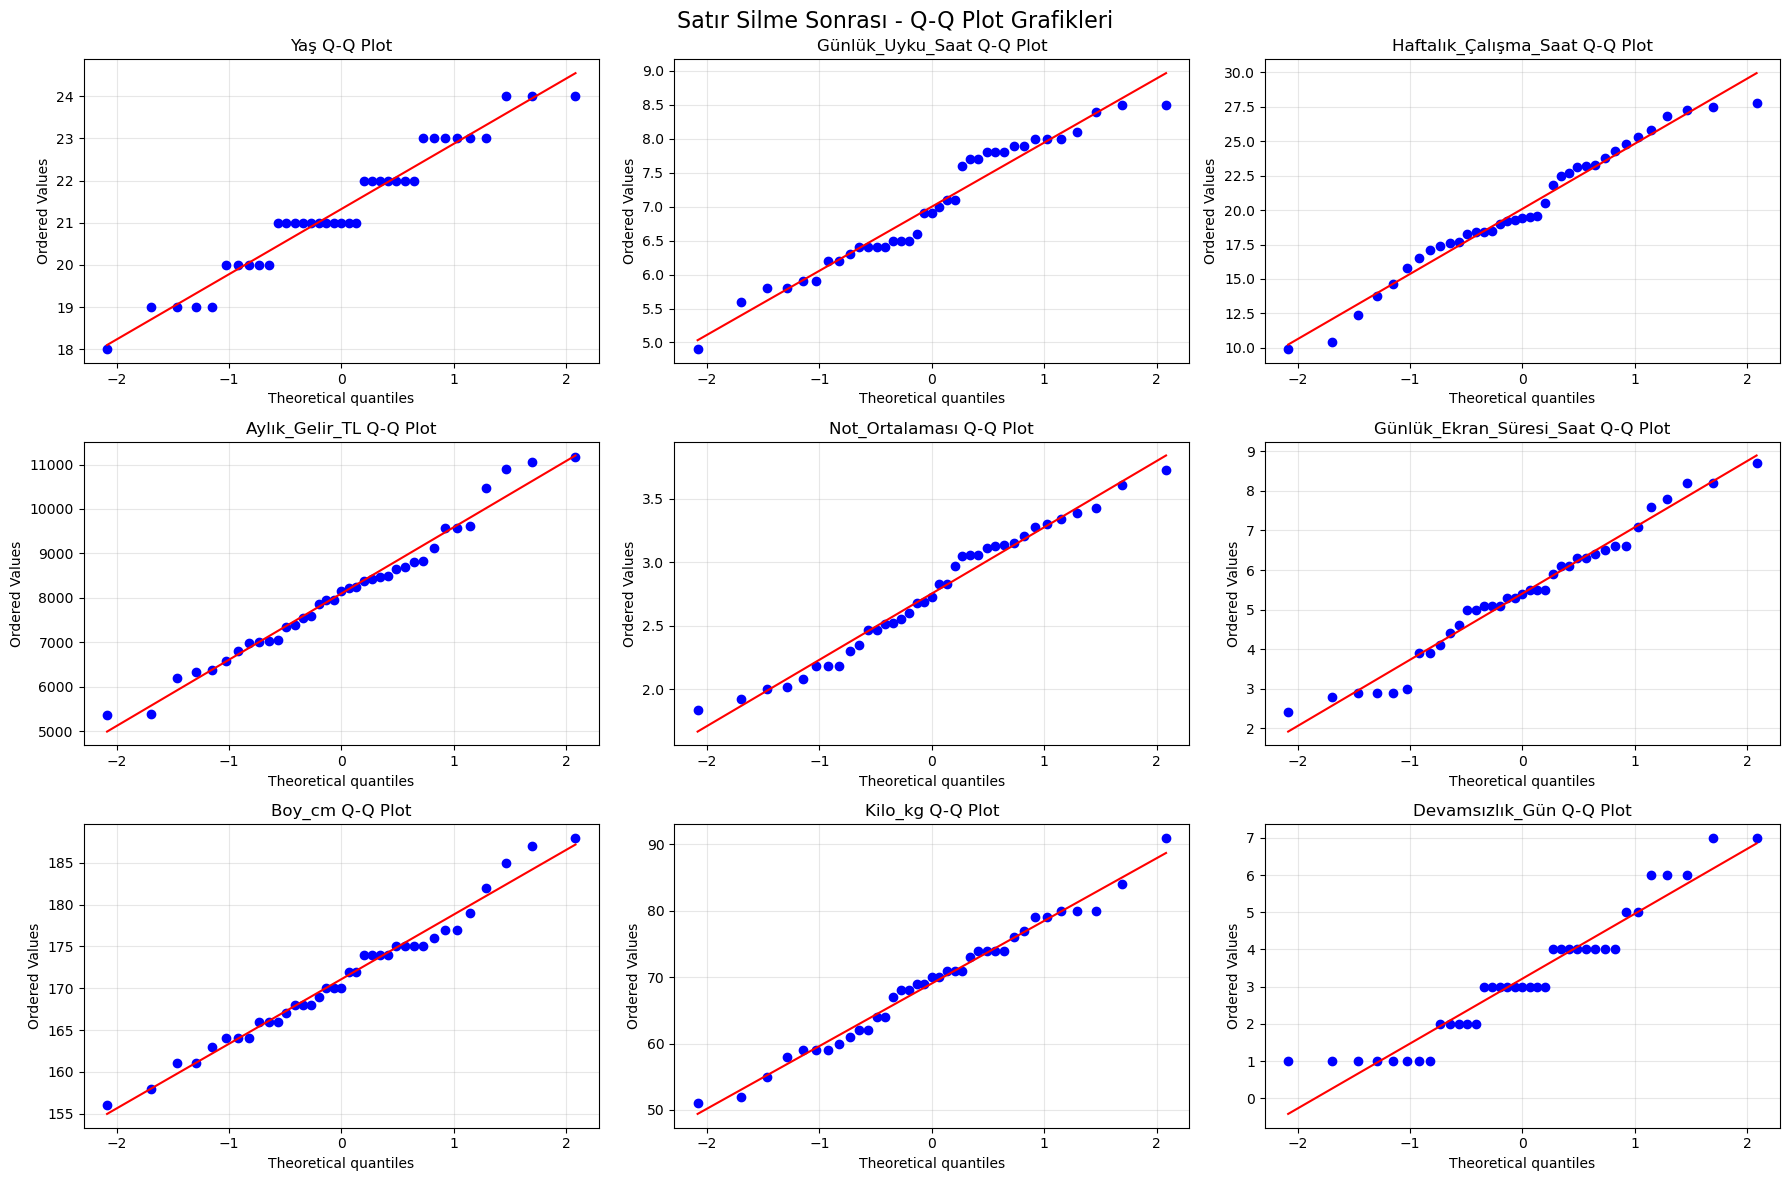

In [77]:
plot_qq_grid(df_clean_drop, numeric_cols, "Satır Silme Sonrası - Q-Q Plot Grafikleri")

### Genel yorum
- Noktaların büyük bölümü referans çizgisine ham veriye göre belirgin biçimde daha yakın hale gelmiştir.
- Q-Q plot açısından en net iyileşme bu aşamada görülmektedir.
- Bunun temel nedeni, aykırı değerleri doğrudan üreten satırların veri setinden tamamen çıkarılmış olmasıdır.

### Değişken bazlı yorum
- **Yaş:** Noktalar çizgiye belirgin biçimde yaklaşmıştır; önceki sert üst kuyruk sapması yoktur.
- **Günlük_Uyku_Saat:** Uyum belirgin şekilde artmıştır; yalnızca hafif uç sapmaları kalmıştır.
- **Haftalık_Çalışma_Saat:** Önceki sağ kuyruk bozulması büyük ölçüde düzelmiştir.
- **Aylık_Gelir_TL:** Oldukça düzgün bir doğrusallık görülmektedir; ciddi iyileşme vardır.
- **Not_Ortalaması:** Merkez ve kuyruklar daha düzgün hale gelmiştir.
- **Günlük_Ekran_Süresi_Saat:** Referans çizgisine uyum belirgin artmıştır.
- **Boy_cm:** Zaten iyi olan uyum daha da temiz görünmektedir.
- **Kilo_kg:** Üst kuyruktaki sert sapma kaybolmuş, çizgiye yakınlık artmıştır.
- **Devamsızlık_Gün:** Ayrık yapı devam ettiği için basamaklı görünüm vardır; buna rağmen önceki kadar sert aykırı sapma yoktur.

### Sonuç
Q-Q plot açısından en başarılı temizlik sonucu satır silme yönteminde görülmektedir. Normaliteye görsel yakınlaşma en fazla bu aşamada sağlanmıştır.

# 19) Baskılama sonrası Q-Q Plot

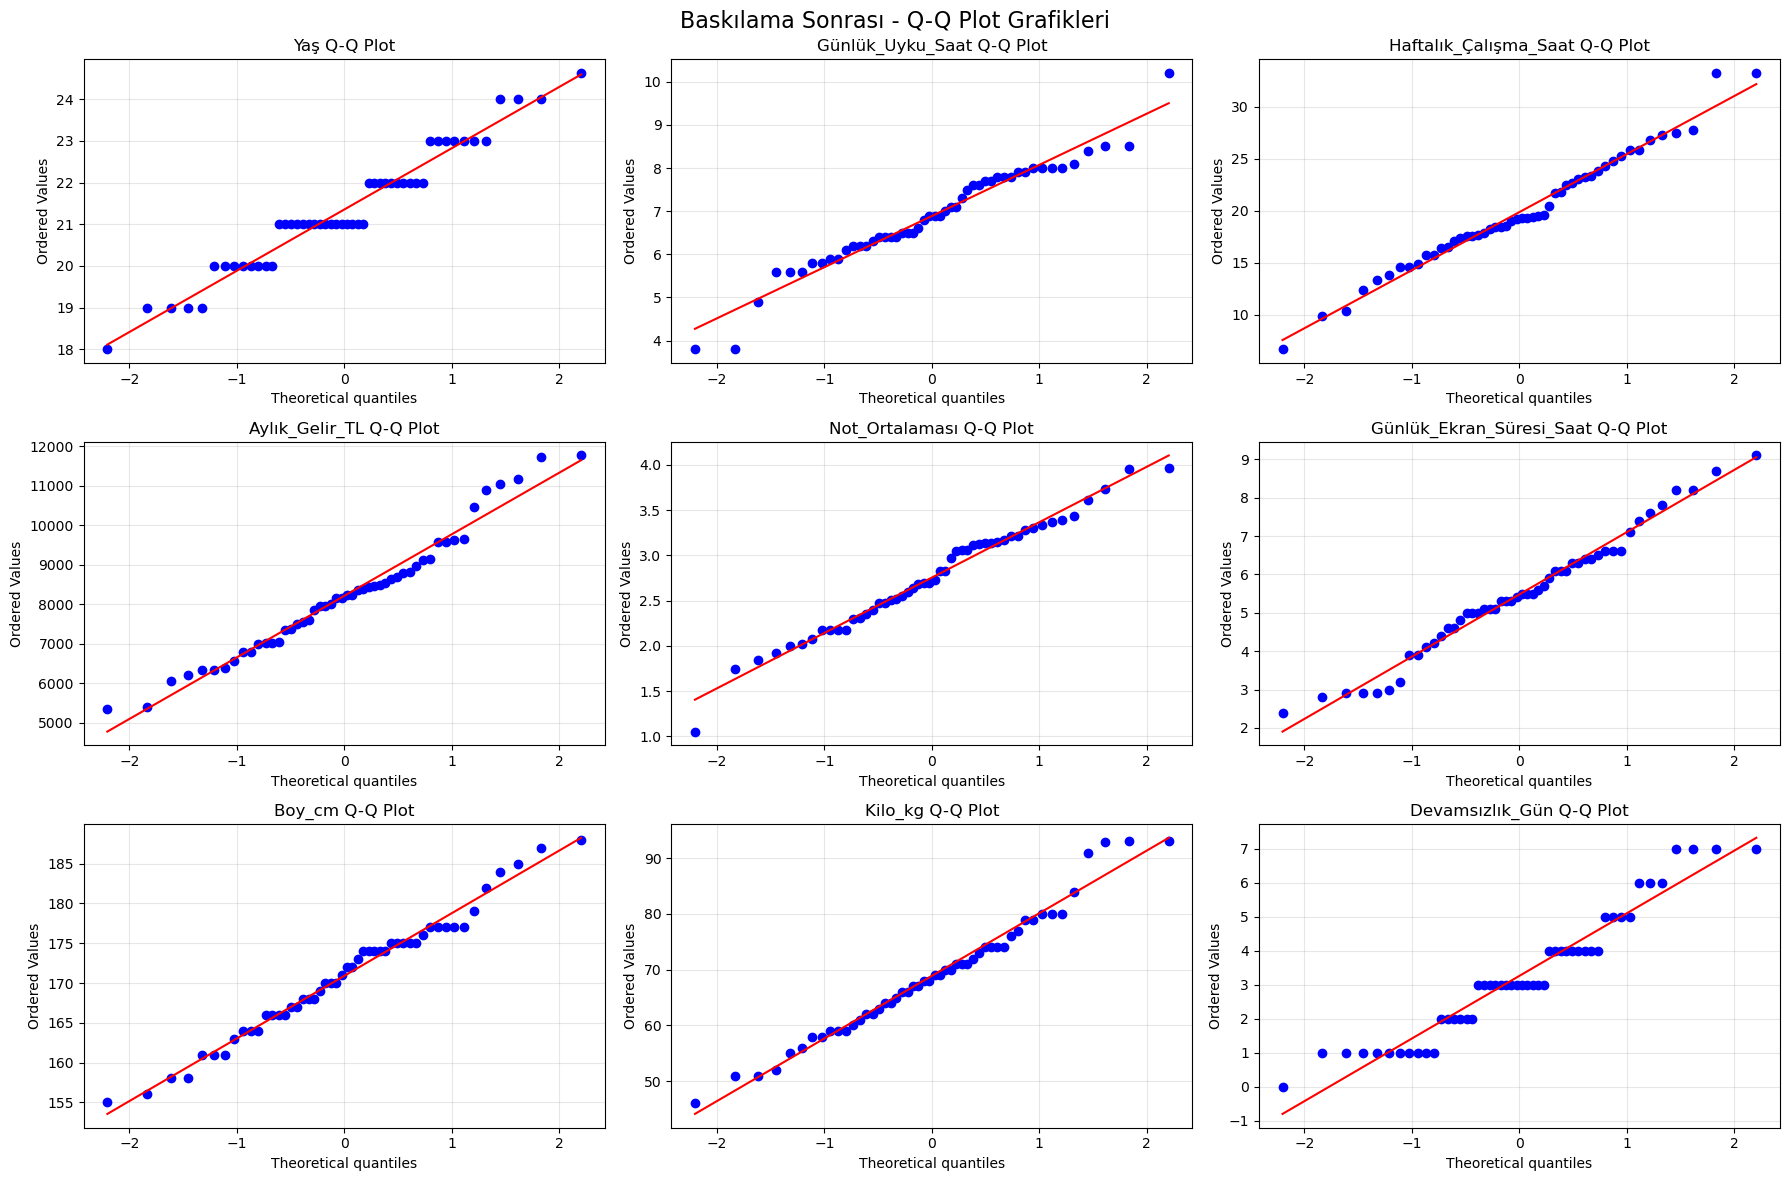

In [78]:
plot_qq_grid(df_clean_capped, numeric_cols, "Baskılama Sonrası - Q-Q Plot Grafikleri")

### Genel yorum
- Ham veriye göre belirgin iyileşme vardır.
- Noktalar çizgiye daha fazla yaklaşmıştır; ancak satır silmeye göre uçlarda küçük sapmalar biraz daha fazla korunmuştur.
- Bunun nedeni, aykırı gözlemlerin tamamen silinmemesi; sınır değerlerde tutulmasıdır.

### Değişken bazlı yorum
- **Yaş:** Önceki aşırı sapma kaybolmuştur; ancak sınıra çekilen üst değer nedeniyle en uçta hafif sapma hissedilir.
- **Günlük_Uyku_Saat:** Merkez iyi, uçlarda hafif sapmalar mevcuttur.
- **Haftalık_Çalışma_Saat:** Genel uyum iyileşmiştir; üst uçta sınıra yığılma nedeniyle hafif bozulma vardır.
- **Aylık_Gelir_TL:** Çok belirgin iyileşme vardır; ancak satır silmeye göre üst kısımda hafif sınır etkisi korunur.
- **Not_Ortalaması:** Çizgiye uyum güçlüdür; küçük kuyruk sapmaları dışında dengelidir.
- **Günlük_Ekran_Süresi_Saat:** Orta kısım iyi uyumludur, uçlarda hafif sapma kalmıştır.
- **Boy_cm:** Çok iyi uyum göstermektedir.
- **Kilo_kg:** Genel uyum iyidir; üst tarafta sınıra toplanan değerlerin etkisiyle hafif sapma vardır.
- **Devamsızlık_Gün:** Ayrık yapı ve sınıra çekilen üst değerler nedeniyle basamaklı görünüm sürmektedir.

### Sonuç
Baskılama sonrası Q-Q plot'lar, ham veriye göre belirgin şekilde daha iyi; ancak satır silme kadar kusursuz değildir. Bununla birlikte veri kaybı olmadan normaliteye yaklaşma sağlanmış olması, bu yöntemin önemli avantajıdır.

# Kaynakça

1 - shashi16. (2025, December 21). Outlier detection and treatment in machine learning. Medium. https://medium.com/%40shashikumargupta443/outlier-detection-and-treatment-in-machine-learning-9cb1792c7535